In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

Q1: Load dataset and show first 5 rows

In [30]:
import os
os.listdir('/content/drive/MyDrive/')
df = pd.read_csv('/content/drive/MyDrive/Dataset 2.csv')
df.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,Female,Basic,23,5,Comedy,13,353,No
1,1002,55,Male,Basic,9,4,Drama,14,317,Yes
2,1003,49,Male,Basic,8,3,Comedy,16,309,No
3,1004,39,Female,Premium,19,5,Drama,45,833,Yes
4,1005,38,Female,Premium,23,5,Sci-Fi,24,804,Yes


Q2: Number of rows and columns

In [13]:
print("Rows and Columns:", df.shape)

Rows and Columns: (750, 10)


Q3: All column names

In [14]:
print("Columns:", df.columns.tolist())

Columns: ['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek', 'DevicesUsed', 'FavoriteGenre', 'AdClicks', 'MonthlySpend', 'SubscriptionRenewed']


Q4: Numerical and categorical features

In [15]:
print("Numerical Features:")
print(df.select_dtypes(include='number').columns.tolist())

print("\nCategorical Features:")
print(df.select_dtypes(exclude='number').columns.tolist())

Numerical Features:
['UserID', 'Age', 'WatchHoursPerWeek', 'DevicesUsed', 'AdClicks', 'MonthlySpend']

Categorical Features:
['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']


Q5: Check missing values

In [16]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
UserID                 0
Age                    0
Gender                 0
SubscriptionType       0
WatchHoursPerWeek      0
DevicesUsed            0
FavoriteGenre          0
AdClicks               0
MonthlySpend           0
SubscriptionRenewed    0
dtype: int64


Q6: Average age

In [17]:
print("Average Age:", df['Age'].mean())

Average Age: 41.824


Q7: Average watch hours per week

In [18]:
print("Avg Watch Hours/Week:", df['WatchHoursPerWeek'].mean())

Avg Watch Hours/Week: 14.236


Q8: Average monthly spending

In [19]:
print("Avg Monthly Spend:", df['MonthlySpend'].mean())

Avg Monthly Spend: 689.9053333333334


Q9: Users per subscription type

In [20]:
print(df['SubscriptionType'].value_counts())

SubscriptionType
Basic      342
Premium    279
VIP        129
Name: count, dtype: int64


Q10: Percentage who renewed

In [21]:
renewed = df['SubscriptionRenewed'].value_counts(normalize=True) * 100
print(renewed)

SubscriptionRenewed
No     53.733333
Yes    46.266667
Name: proportion, dtype: float64


Q11: Convert categories to numbers

In [22]:
df_encoded = df.copy()
le = LabelEncoder()

for col in ['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,UserID,Age,Gender,SubscriptionType,WatchHoursPerWeek,DevicesUsed,FavoriteGenre,AdClicks,MonthlySpend,SubscriptionRenewed
0,1001,22,0,0,23,5,1,13,353,0
1,1002,55,1,0,9,4,2,14,317,1
2,1003,49,1,0,8,3,1,16,309,0
3,1004,39,0,1,19,5,2,45,833,1
4,1005,38,0,1,23,5,5,24,804,1


Q12: Define X (features) and y (target)

In [23]:
X = df_encoded.drop(columns=['UserID', 'SubscriptionRenewed'])
y = df_encoded['SubscriptionRenewed']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (750, 8)
Target shape: (750,)


Q13: Split into train and test sets

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (600, 8)
Testing size: (150, 8)


Q14: Train Decision Tree

In [25]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
print("Decision Tree trained!")

Decision Tree trained!


 Q15: Check accuracy

In [26]:
dt_predictions = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_predictions)
print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy: 56.0 %


Q16: Confusion matrix

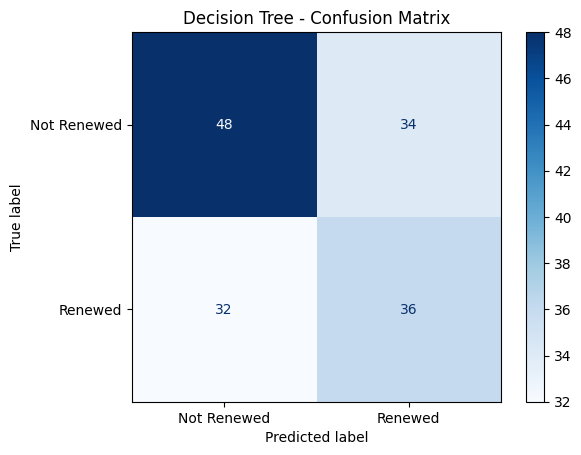

In [27]:
cm = confusion_matrix(y_test, dt_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Renewed', 'Renewed'])
disp.plot(cmap='Blues')
plt.title("Decision Tree - Confusion Matrix")
plt.show()

Q17 & Q18: Train KNN and compare

In [28]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_predictions = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_predictions)

print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")
print("KNN Accuracy:          ", round(knn_accuracy * 100, 2), "%")

if dt_accuracy > knn_accuracy:
    print("→ Decision Tree performed better")
else:
    print("→ KNN performed better")

Decision Tree Accuracy: 56.0 %
KNN Accuracy:           63.33 %
→ KNN performed better
